# 1_EDA



## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'dod7dumu05u6cn'
os.environ['DataZoneDomainId'] = 'dzd-crnhdsp0s7155z'
os.environ['DataZoneEnvironmentId'] = 'deeuj7l8vp1nzb'
os.environ['DataZoneDomainRegion'] = 'us-east-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "dod7dumu05u6cn",
                "DataZoneDomainId": "dzd-crnhdsp0s7155z",
                "DataZoneEnvironmentId": "deeuj7l8vp1nzb",
                "DataZoneDomainRegion": "us-east-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


df_bronze = pd.read_catalog_table(
    database='sin-exam_db', 
    table='bronze_sin_exam_bronze_877617909831',
    encoding='latin-1'
)


In [0]:
print("=" * 80)
print("1. INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)

print("\n--- Info general ---")
df_bronze.info()

print("\n--- Dimensiones ---")
print(f"Número de filas: {df_bronze.shape[0]:,}")
print(f"Número de columnas: {df_bronze.shape[1]}")

print("\n--- Primeras 5 filas ---")
display(df_bronze.head())


1. INFORMACIÓN GENERAL DEL DATASET

--- Info general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [0]:
print("\n" + "=" * 80)
print("2. ANÁLISIS DE TIPOS DE DATOS")
print("=" * 80)

df_types = df_bronze.dtypes.reset_index()
df_types.columns = ["columna", "tipo"]
display(df_types)



2. ANÁLISIS DE TIPOS DE DATOS


,columna,tipo
0,Row ID,int64
1,Order ID,object
2,Order Date,object
3,Ship Date,object
4,Ship Mode,object
5,Customer ID,object
6,Customer Name,object
7,Segment,object
8,Country,object
9,City,object


In [0]:
print("\n" + "=" * 80)
print("3. ANÁLISIS DE VALORES NULOS")
print("=" * 80)

null_df = pd.DataFrame({
    "null_count": df_bronze.isnull().sum()
})
null_df["null_pct"] = (null_df["null_count"] / len(df_bronze)) * 100
null_df = null_df.sort_values("null_pct", ascending=False)

display(null_df)

# Only plot if there are null values
null_data = null_df[null_df["null_count"] > 0]
if not null_data.empty:
    null_data["null_pct"].plot(
        kind="bar",
        title="Porcentaje de valores nulos por columna"
    )
    plt.ylabel("% de nulos")
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No se encontraron valores nulos en el dataset")



3. ANÁLISIS DE VALORES NULOS


,null_count,null_pct
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0



✓ No se encontraron valores nulos en el dataset



4. ESTADÍSTICAS DESCRIPTIVAS - COLUMNAS NUMÉRICAS


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


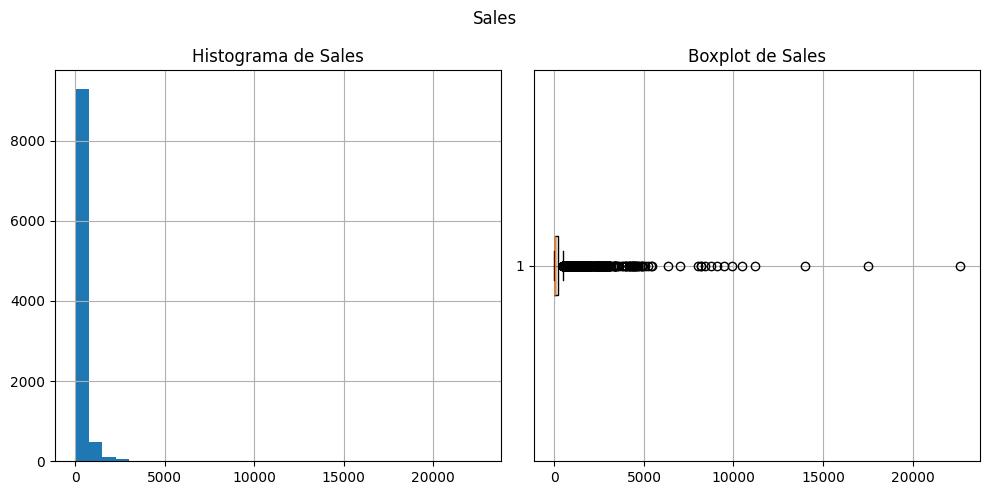

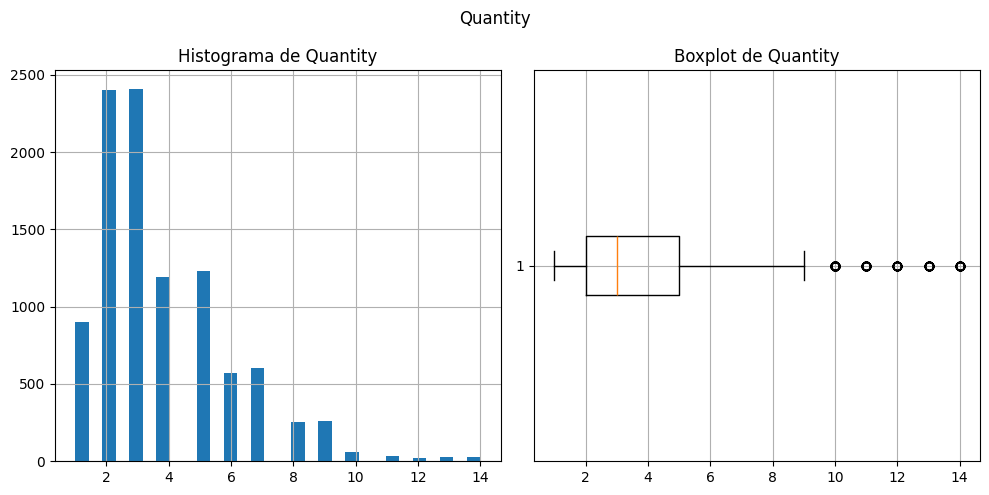

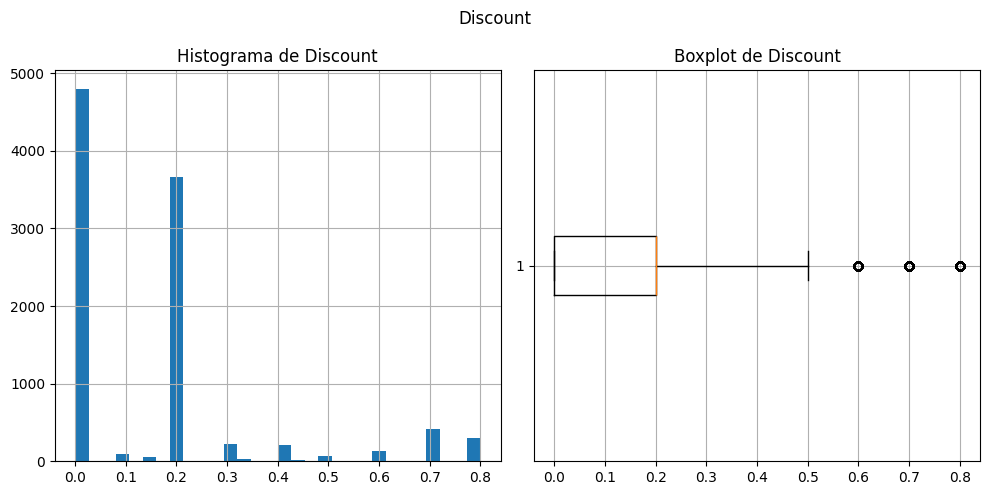

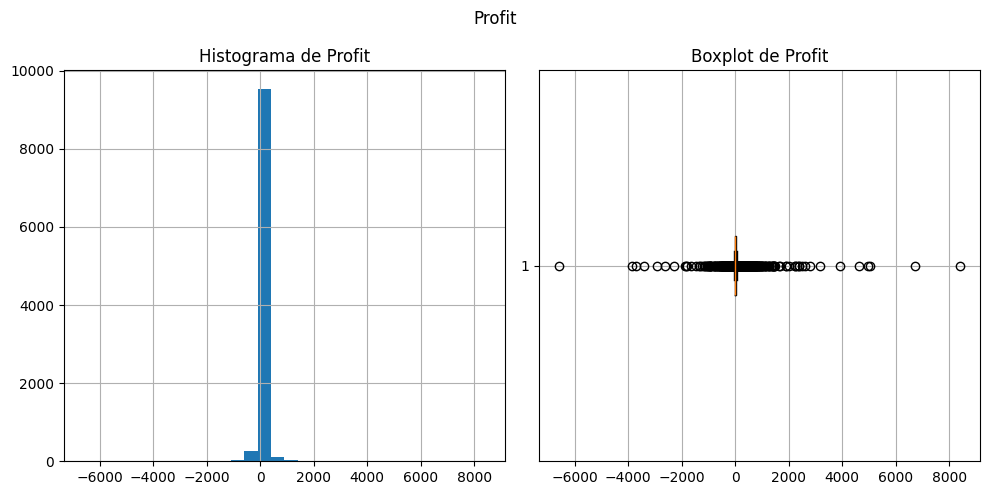

In [0]:
print("\n" + "=" * 80)
print("4. ESTADÍSTICAS DESCRIPTIVAS - COLUMNAS NUMÉRICAS")
print("=" * 80)

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
display(df_bronze[numeric_cols].describe())

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2)

    df_bronze[col].hist(bins=30, ax=axes[0])
    axes[0].set_title(f"Histograma de {col}")

    axes[1].boxplot(df_bronze[col].dropna(), vert=False)
    axes[1].set_title(f"Boxplot de {col}")

    plt.suptitle(col)
    plt.tight_layout()
    plt.show()



5. ANÁLISIS DE COLUMNAS CATEGÓRICAS


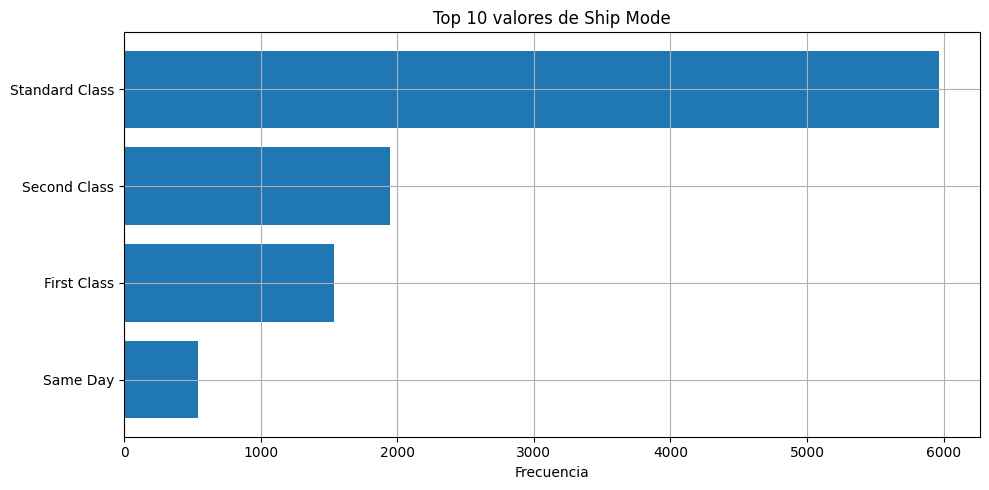

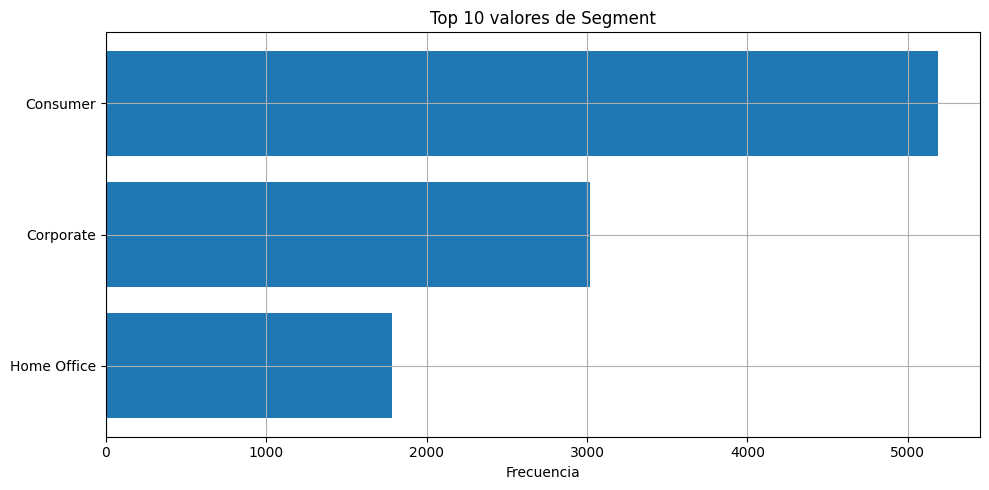

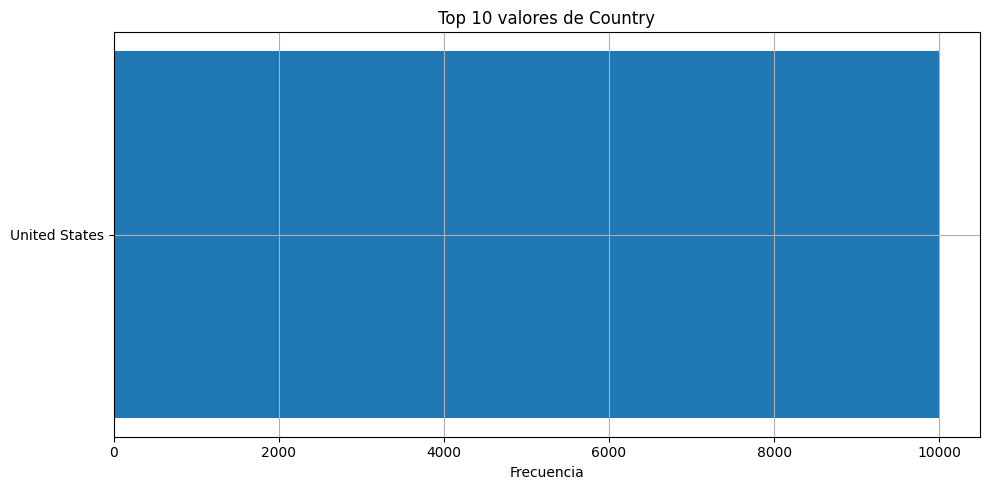

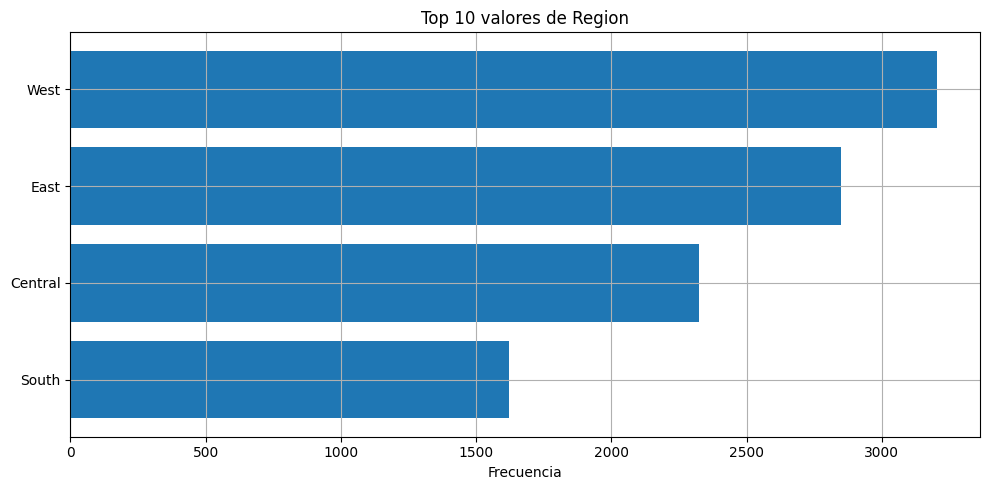

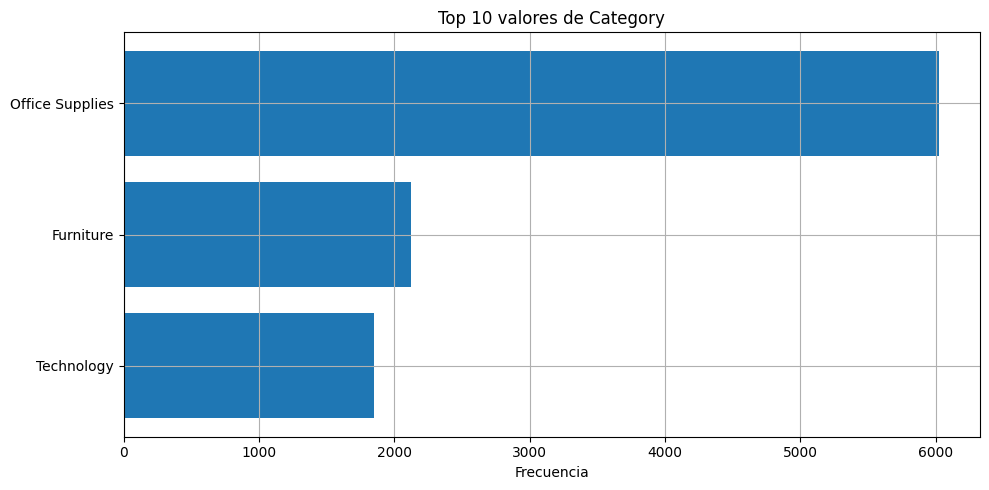

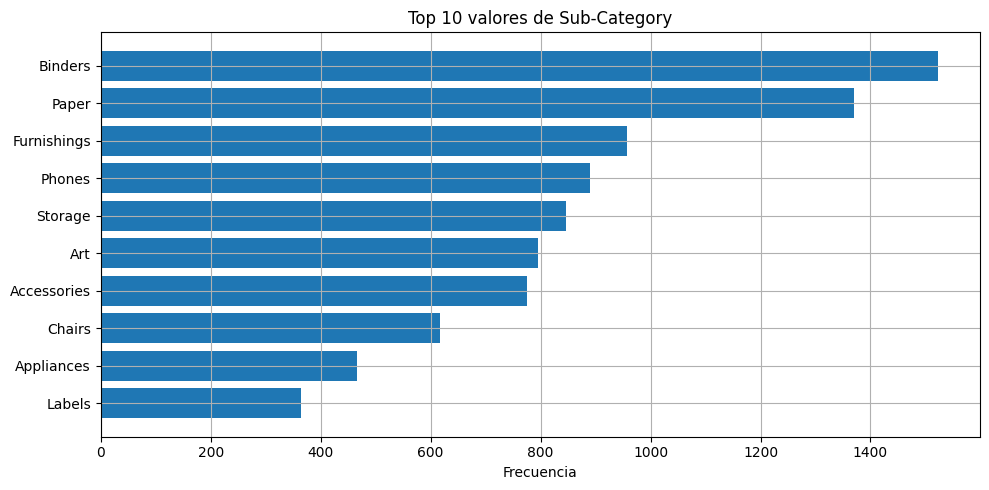

In [0]:
print("\n" + "=" * 80)
print("5. ANÁLISIS DE COLUMNAS CATEGÓRICAS")
print("=" * 80)

categorical_cols = [
    'Ship Mode', 'Segment', 'Country',
    'Region', 'Category', 'Sub-Category'
]

for col in categorical_cols:
    vc = df_bronze[col].value_counts().head(10)

    plt.barh(vc.index, vc.values)
    plt.title(f"Top 10 valores de {col}")
    plt.xlabel("Frecuencia")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [0]:
print("\n" + "=" * 80)
print("6. ANÁLISIS DE CARDINALIDAD")
print("=" * 80)

cardinality_df = pd.DataFrame({
    "valores_unicos": df_bronze.nunique(),
    "porcentaje_unico": (df_bronze.nunique() / len(df_bronze)) * 100
}).sort_values("porcentaje_unico", ascending=False)

display(cardinality_df)



6. ANÁLISIS DE CARDINALIDAD


,valores_unicos,porcentaje_unico
Row ID,9994,100.000000
Profit,7287,72.913748
Sales,5825,58.284971
Order ID,5009,50.120072
Product ID,1862,18.631179
Product Name,1850,18.511107
Ship Date,1334,13.348009
Order Date,1237,12.377426
Customer ID,793,7.934761
Customer Name,793,7.934761



7. ANÁLISIS TEMPORAL
Rango de fechas de pedidos:
2014-01-03 00:00:00 → 2017-12-30 00:00:00
Rango de fechas de envío:
2014-01-07 00:00:00 → 2018-01-05 00:00:00


/tmp/ipykernel_81/1248185678.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


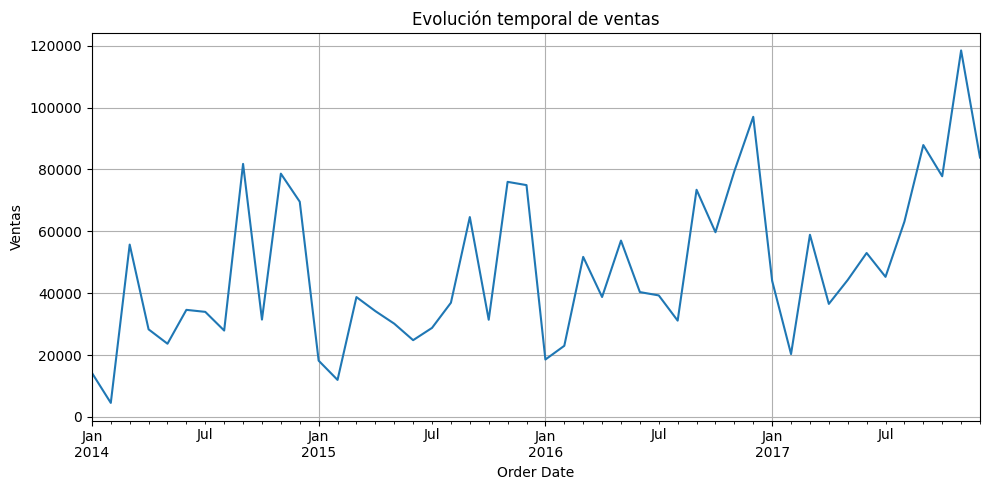

In [0]:
print("\n" + "=" * 80)
print("7. ANÁLISIS TEMPORAL")
print("=" * 80)

df_bronze["Order Date"] = pd.to_datetime(df_bronze["Order Date"])
df_bronze["Ship Date"] = pd.to_datetime(df_bronze["Ship Date"])

print("Rango de fechas de pedidos:")
print(df_bronze["Order Date"].min(), "→", df_bronze["Order Date"].max())

print("Rango de fechas de envío:")
print(df_bronze["Ship Date"].min(), "→", df_bronze["Ship Date"].max())


sales_time = (
    df_bronze
    .set_index("Order Date")
    .resample("M")["Sales"]
    .sum()
)

sales_time.plot(title="Evolución temporal de ventas")
plt.ylabel("Ventas")
plt.tight_layout()
plt.show()


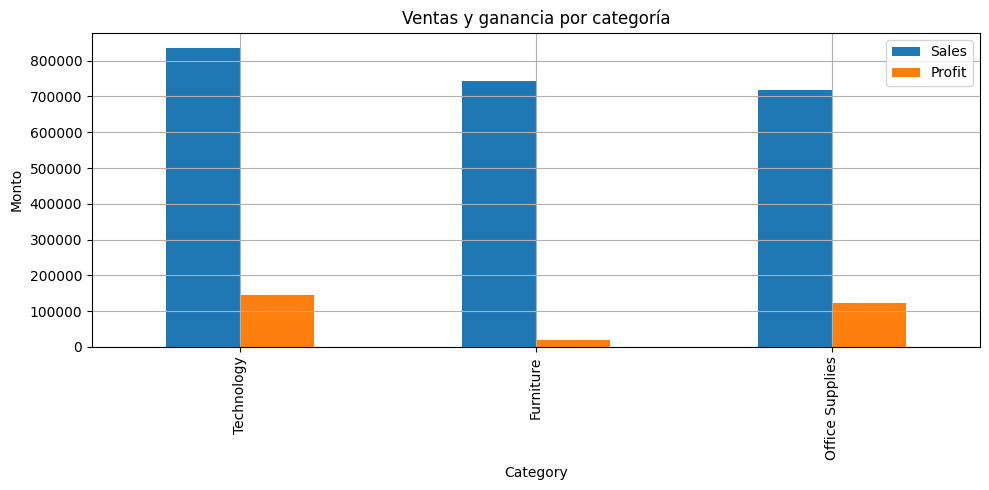

In [0]:
sales_category = (
    df_bronze
    .groupby("Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

sales_category.plot(kind="bar", title="Ventas y ganancia por categoría")
plt.ylabel("Monto")
plt.tight_layout()
plt.show()


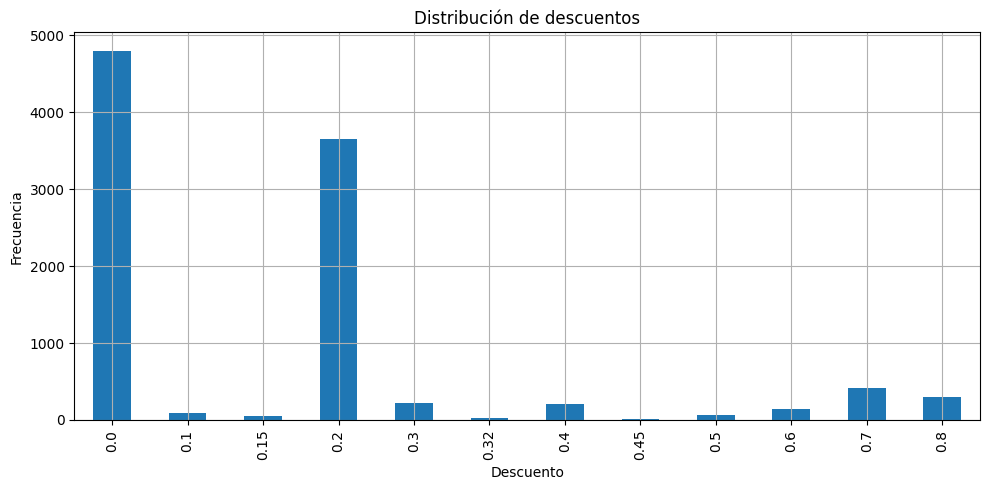

In [0]:
df_bronze["Discount"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribución de descuentos"
)
plt.xlabel("Descuento")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


In [0]:
print("\n" + "=" * 80)
print("10. DETECCIÓN DE OUTLIERS")
print("=" * 80)

display(df_bronze[numeric_cols].quantile([0.01, 0.25, 0.5, 0.75, 0.99]))



10. DETECCIÓN DE OUTLIERS


,Sales,Quantity,Discount,Profit
0.01,2.2860,1.0,0.0,-319.264953
0.25,17.2800,2.0,0.0,1.728750
0.50,54.4900,3.0,0.2,8.666500
0.75,209.9400,5.0,0.2,29.364000
0.99,2481.6946,11.0,0.8,580.657882


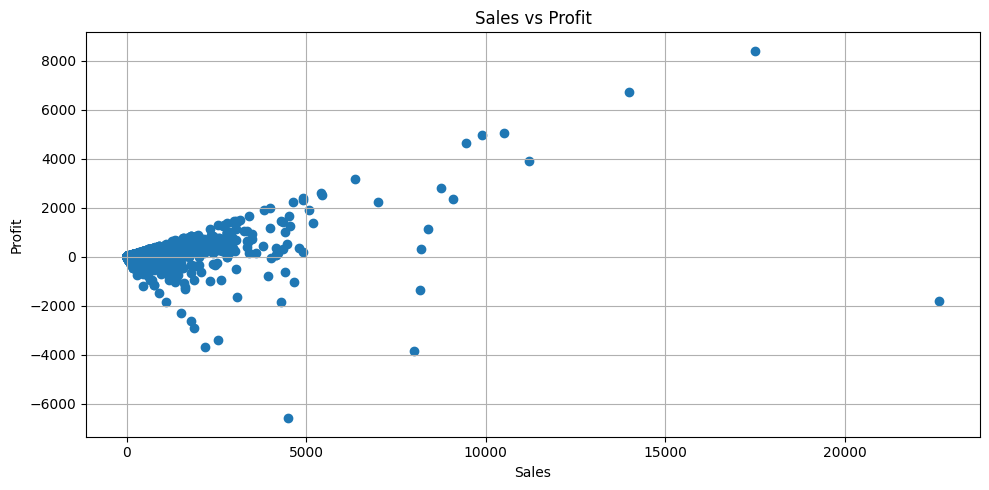

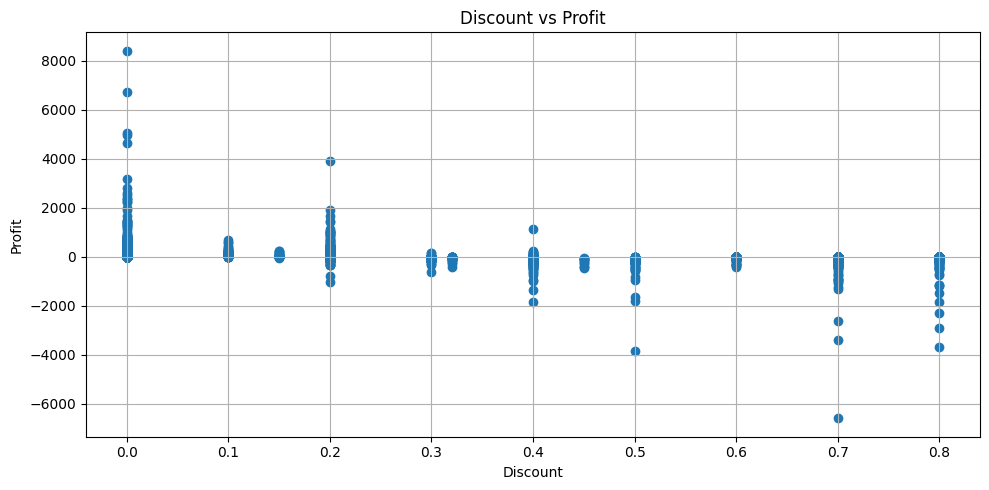

In [0]:
plt.scatter(df_bronze["Sales"], df_bronze["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

plt.scatter(df_bronze["Discount"], df_bronze["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


In [0]:
print("\n" + "=" * 80)
print("12. ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 80)

print("Registros duplicados:", df_bronze.duplicated().sum())

string_cols = df_bronze.select_dtypes(include="object").columns
for col in string_cols[:5]:
    blank_count = ((df_bronze[col].isnull()) | (df_bronze[col].str.strip() == "")).sum()
    print(f"{col:30} -> {blank_count:,} valores vacíos/nulos")



12. ANÁLISIS DE CALIDAD DE DATOS
Registros duplicados: 0
Order ID                       -> 0 valores vacíos/nulos
Ship Mode                      -> 0 valores vacíos/nulos
Customer ID                    -> 0 valores vacíos/nulos
Customer Name                  -> 0 valores vacíos/nulos
Segment                        -> 0 valores vacíos/nulos


## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()